<center>

# Longitudinal analysis of heart rate variability as it pertains to anxiety and readiness
### An exploratory single-case study
##### Tucker Paron

</center>

#### Setup
Load in supporting file containing packages and functions.

In [60]:
%run csys387_final_project_functions.ipynb

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Read in data and create appropriate subsets and mergers for analysis.

In [61]:
import numpy as np

In [122]:
# read data
df = pd.read_csv('data.csv')

# filter to only readiness readings
readiness_df = df[df['Type'] == 'readiness']

# create df for just physical/mental LOGS
other_list = ['sleep', 'mood', 'exercise', 'weight', 'illness', 'energy', 'soreness', 'stress']
other_df = df[df['Type'].isin(other_list)] # can't remember purpose of this line...

# create df of only BIOMETRIC numeric variables
numeric_df = readiness_df.select_dtypes(include='number')
numeric_df = numeric_df.fillna(numeric_df.mean()) # fill na's with mean of column

# create df of just the daily NOTES along with HRV and Morning Readiness
string_df = pd.DataFrame(readiness_df[['Notes', 'HRV', 'Morning Readiness']])

# create a df just for our self-created and self-measured TAGS
tags_df = readiness_df['Tags'].str.get_dummies(sep=',')
tags_df = tags_df.rename(columns=appropriate_column_names) # rename informally named variables

# combine numeric BIOMETRIC data with binary TAGS data
boolean_df = pd.concat([numeric_df[['HRV', 'Morning Readiness', 'LF/HF Ratio', 'Low Frequency Power', 'High Frequency Power', 'Total Power']], tags_df], axis=1)


#### Exploration
- Look at Pearson correlations between all standard EliteHRV biometrics
    - This will help to determine multi-collinearity, so as to reduce variables in analysis
- Plot time series of HRV and Readiness to indentify trends or recall significant moments

<ipython-input-123-54e03bd65d28>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_df.loc[:, 'Date'] =  pd.to_datetime(readiness_df['Date Time Start'])


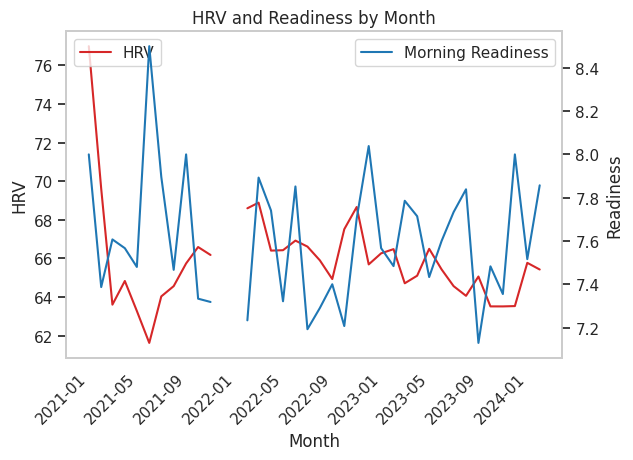

In [123]:
### line plot of HRV and Readiness over time
ts_df = readiness_df[['Date Time Start', 'Morning Readiness', 'HRV']]
ts_df.loc[:, 'Date'] =  pd.to_datetime(readiness_df['Date Time Start'])

# set the 'Date' column as the index
ts_df.set_index('Date', inplace=True)

# get average HRV by month, excluding November and December of 2021
monthly_df = ts_df.loc[(ts_df.index < '2021-11-01') | (ts_df.index > '2022-01-01')].drop(columns={'Date Time Start'}).resample('M').mean()

fig, ax1 = plt.subplots()

# plot 'HRV' data on the left y-axis
ax1.plot(monthly_df['HRV'], color='tab:red', label='HRV')
ax1.set_ylabel('HRV')

# plot 'Readiness' data on the right y-axis
ax2 = ax1.twinx()
ax2.plot(monthly_df['Morning Readiness'], color='tab:blue', label='Morning Readiness')
ax2.set_ylabel('Readiness')

# labels
ax1.set_xlabel('Month')
ax1.set_title('HRV and Readiness by Month')

# Format the x-axis ticks to show only the month and year
fig.autofmt_xdate(rotation=45)

# show legend
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# remove background grid lines
ax1.grid(visible=False)
ax2.grid(visible=False)

plt.savefig('images/times-series.png', dpi=300, bbox_inches='tight')

#### Anxiety: Relationship to HRV and Appraisal
###### Processing & Exploration
- Get a subset of the data that includes only observations after the first use of the anxiety TAG
- Check for correlation between Anxiety and HRV

In [124]:
# get subset of data starting from first instance of 'Anxious' TAG
first_appearance = boolean_df[boolean_df['Anxious'] == 1].index[0]
subset_boolean_df = boolean_df.loc[first_appearance:].copy()

# check for correlation between Anxiety and HRV
corr, p_value = pointbiserialr(subset_boolean_df['Anxious'], subset_boolean_df['HRV'])
print("Point Biserial corr. coef. between 'Anxious' and 'HRV':", round(corr, 4), "(p-value of", str(round(p_value, 5)) +  ")")

Point Biserial corr. coef. between 'Anxious' and 'HRV': -0.0103 (p-value of 0.75182)


###### Analysis and Visualization
- Make a table of various biometrics vs ANS Balance (what is different about Sympathetic state)
    - T-test to check for significant differences in biometric averages between P and S
- Make a table of mean HRV, Readiness, and LF/HF Ratio by anxiety appraisal
    - T-test to check for significant differences in biometric averages between appraisal strategies
- Calculate correlations between anxiety, excitement, HRV, Readiness, LF/HF Ratio, Low Frequency Power, and High Frequency Power
    - Make a clustered bar plot representing this

In [125]:
selected_vars = ['HRV', 'Balance', 'LF/HF Ratio', 'Low Frequency Power', 'High Frequency Power', 'Total Power']
avg_by_balance = readiness_df[selected_vars].groupby('Balance').mean().reset_index()
avg_by_balance['n'] = readiness_df.groupby('Balance').size().values
tabulate(avg_by_balance, headers=['Balance'] + selected_vars + ['n'], tablefmt='orgtbl')

'|   Balance | HRV   |   Balance |   LF/HF Ratio |   Low Frequency Power |   High Frequency Power |   Total Power |   n |\n|-----------+-------+-----------+---------------+-----------------------+------------------------+---------------+-----|\n|         0 | PS    |   69      |       1.83637 |               4261.01 |                2613.33 |       6874.34 | 478 |\n|         1 | S     |   62.6827 |       2.04574 |               1984.9  |                1022.48 |       3007.37 | 520 |'

In [126]:
# Subset the data for the S and non-S groups
selected_vars = ['HRV', 'LF/HF Ratio', 'Low Frequency Power', 'High Frequency Power', 'Total Power']
s_data = readiness_df[readiness_df['Balance'] == 'S'][selected_vars]
non_s_data = readiness_df[readiness_df['Balance'] != 'S'][selected_vars]

# Perform a two-sample t-test for each variable
for var in selected_vars:
    s_mean = s_data[var].mean()
    non_s_mean = non_s_data[var].mean()
    s_std = s_data[var].std()
    non_s_std = non_s_data[var].std()
    t_stat, p_val = ttest_ind(s_data[var], non_s_data[var], equal_var=False)
    print(f"{var} - S group mean: {s_mean:.2f}, Non-S group mean: {non_s_mean:.2f}, p-value: {p_val:.4f}")

HRV - S group mean: 62.68, Non-S group mean: 69.01, p-value: 0.0000
LF/HF Ratio - S group mean: 2.05, Non-S group mean: 1.83, p-value: 0.0101
Low Frequency Power - S group mean: 1984.90, Non-S group mean: 4246.14, p-value: 0.0000
High Frequency Power - S group mean: 1022.48, Non-S group mean: 2610.81, p-value: 0.0000
Total Power - S group mean: 3007.37, Non-S group mean: 6856.96, p-value: 0.0000


In [127]:
# separate observations by appraisal
appraisals = [ (subset_boolean_df['Anxious'] == 1),
               (subset_boolean_df['Excited'] == 1),
               (subset_boolean_df['Anxious'] == 1) & (subset_boolean_df['Excited'] == 0),
               (subset_boolean_df['Anxious'] == 0) & (subset_boolean_df['Excited'] == 1),
               (subset_boolean_df['Anxious'] == 1) & (subset_boolean_df['Excited'] == 1),
               (subset_boolean_df['Anxious'] == 0) & (subset_boolean_df['Excited'] == 0) ]

labels = ['Anxious', 'Excited', 'Anxious, not Excited', 'not Anxious, Excited', 'Anxious, Excited', 'Neither'] # appraisal types

mean_hrv = []
mean_readiness = []
mean_lfhf = []
mean_power = []

# calculate means by appraisal
for app in appraisals:
    mean_hrv.append(subset_boolean_df[app]['HRV'].mean())
    mean_readiness.append(subset_boolean_df[app]['Morning Readiness'].mean())
    mean_lfhf.append(subset_boolean_df[app]['LF/HF Ratio'].mean())
    mean_power.append(subset_boolean_df[app]['Total Power'].mean())

# create and output table
table = [ [ labels[i], f"{mean_hrv[i]:.2f}", f"{mean_readiness[i]:.2f}", f"{mean_lfhf[i]:.2f}", f"{mean_power[i]:.2f}", np.sum(appraisals[i]) ] for i in range(len(labels)) ]

print(tabulate(table, headers=['Appraisal', 'Mean HRV', 'Mean Readiness', 'Mean LF/HF Ratio', 'Total Power', 'n'], tablefmt='orgtbl'))


| Appraisal            |   Mean HRV |   Mean Readiness |   Mean LF/HF Ratio |   Total Power |   n |
|----------------------+------------+------------------+--------------------+---------------+-----|
| Anxious              |      65.53 |             7.58 |               1.93 |       4716.12 | 509 |
| Excited              |      65.65 |             7.55 |               1.94 |       4726.56 | 636 |
| Anxious, not Excited |      65.15 |             7.2  |               2.51 |       5654.68 |  20 |
| not Anxious, Excited |      66.01 |             7.41 |               2.04 |       4889.02 | 147 |
| Anxious, Excited     |      65.55 |             7.6  |               1.91 |       4677.73 | 489 |
| Neither              |      65.45 |             7.7  |               1.94 |       4613.47 | 292 |


In [128]:
# perform t-test for Anxious, not excited and Anxious, excited groups
for i in range(len(selected_vars)):
    _, p_val = ttest_ind(subset_boolean_df[appraisals[0]][selected_vars[i]],
                         subset_boolean_df[appraisals[1]][selected_vars[i]])
    print(f"{selected_vars[i]} - p-value: {p_val:.4f}")

HRV - p-value: 0.6666
LF/HF Ratio - p-value: 0.9148
Low Frequency Power - p-value: 0.9742
High Frequency Power - p-value: 0.9184
Total Power - p-value: 0.9819


[Text(0, 0, 'Anxious'),
 Text(1, 0, 'Excited'),
 Text(2, 0, 'Anxious, not Excited'),
 Text(3, 0, 'not Anxious, Excited'),
 Text(4, 0, 'Anxious, Excited'),
 Text(5, 0, 'Neither')]

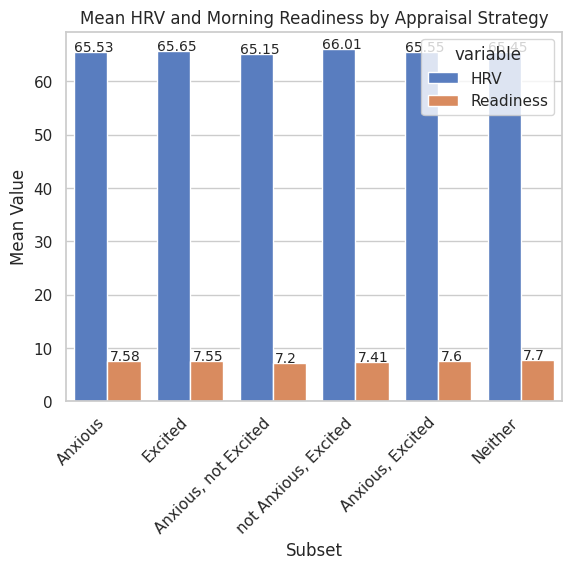

In [129]:
# Create a dataframe with the mean HRV and Morning Readiness values for each subset
df = pd.DataFrame({
    'HRV': mean_hrv,
    'Readiness': mean_readiness,
    'Subset': labels
})

# Create a clustered bar plot with the mean HRV and Morning Readiness values for each subset
sns.set(style='whitegrid')
fig, ax = plt.subplots()
sns.barplot(x='Subset', y='value', hue='variable', data=pd.melt(df, ['Subset']), palette='muted', ax=ax)

# Add axis labels and a title
ax.set_ylabel('Mean Value')
ax.set_title('Mean HRV and Morning Readiness by Appraisal Strategy')

# Add annotations with mean values
for i, app in enumerate(appraisals):
    mean_hrv_value = round(mean_hrv[i], 2)
    mean_readiness_value = round(mean_readiness[i], 2)
    ax.text(i-0.4, mean_hrv_value+0.1, str(mean_hrv_value), fontsize=10)
    ax.text(i+0.03, mean_readiness_value+0.1, str(mean_readiness_value), fontsize=10)

# Save and show the plot
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
#plt.savefig('images/appraisal_bar.png', dpi=300, bbox_inches='tight')

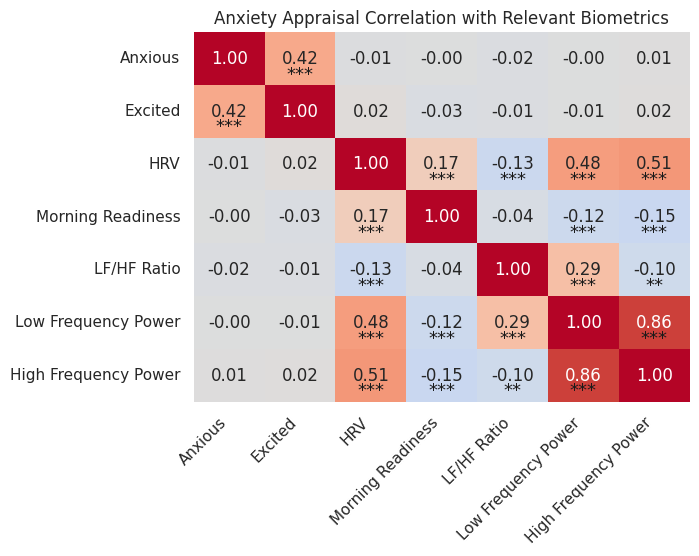

In [130]:
# select columns of interest
cols_of_interest = ['Anxious', 'Excited', 'HRV', 'Morning Readiness', 'LF/HF Ratio', 'Low Frequency Power', 'High Frequency Power']
corr_plot_data = subset_boolean_df[cols_of_interest]

# compute the correlation matrix with p-values and test names
corr_matrix = corr_plot_data.corr(method=custom_corr)
pval_matrix = corr_plot_data.corr(method=custom_p)

# make heatmap
fig, ax = plt.subplots()
sns.heatmap(corr_matrix, cmap='coolwarm',annot=True, center=0, ax=ax, cbar=False, fmt='.2f')

# add p-values to map
rows, cols = corr_matrix.shape
for i in range(rows):
    for j in range(cols):
        if i != j:
            pval = pval_matrix.iloc[i, j]
            if pval < 0.001:
                ax.text(j+0.5, i+0.8, "***", ha="center", va="center", fontsize=13, color="k")
            elif pval < 0.01:
                ax.text(j+0.5, i+0.8, "**", ha="center", va="center", fontsize=13, color="k")
            elif pval < 0.05:
                ax.text(j+0.5, i+0.8, "*", ha="center", va="center", fontsize=13, color="k")


ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Anxiety Appraisal Correlation with Relevant Biometrics')
plt.savefig('images/appraisal_cor.png', dpi=300, bbox_inches='tight')

#### Tags!
###### Processing
Get the correlations for all tags with HRV and with Readiness (check for significance!).
Identify the top ten for each.

In [131]:
# Calculate correlation with HRV using point-biserial correlation
corr_hrv = pd.Series()
pval_hrv = pd.Series()
for col in boolean_df.columns[6:]:
    if boolean_df[col].nunique() == 2:  # check if binary
        corr_hrv[col] = pointbiserialr(boolean_df[col], boolean_df['HRV'])[0]
        pval_hrv[col] = pointbiserialr(boolean_df[col], boolean_df['HRV'])[1]
    else:
        corr_hrv[col] = pearsonr(boolean_df[col],boolean_df['HRV'])[0]
        pval_hrv[col] = pearsonr(boolean_df[col],boolean_df['HRV'])[1]


# sort by absolute correlation value and select top 10
top_10_hrv = corr_hrv.abs().nlargest(10).sort_values(ascending=False)

# Calculate correlation with Readiness using point-biserial correlation
corr_readiness = pd.Series()
pval_readiness = pd.Series()
for col in boolean_df.columns[6:]:
    if boolean_df[col].nunique() == 2:  # check if binary
        corr_readiness[col] = pointbiserialr(boolean_df[col], boolean_df['Morning Readiness'])[0]
        pval_readiness[col] = pointbiserialr(boolean_df[col], boolean_df['Morning Readiness'])[1]
    else:
        corr_readiness[col] = pearsonr(boolean_df[col], boolean_df['Morning Readiness'])[0]
        pval_readiness[col] = pearsonr(boolean_df[col], boolean_df['Morning Readiness'])[1]

# sort by absolute correlation value and select top 10
top_10_readiness = corr_readiness.abs().nlargest(10).sort_values(ascending=False)

# Get the number of appearances for each variable
n_appearances = boolean_df.iloc[:, 5:].sum()

<ipython-input-131-9001cfa5892b>:2: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  corr_hrv = pd.Series()
<ipython-input-131-9001cfa5892b>:3: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  pval_hrv = pd.Series()
<ipython-input-131-9001cfa5892b>:17: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  corr_readiness = pd.Series()
<ipython-input-131-9001cfa5892b>:18: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  pval_readiness = pd.Series()


###### Visualization
- Plots of Tags with highest correlations with HRV and Readiness (denoting statistical significance)

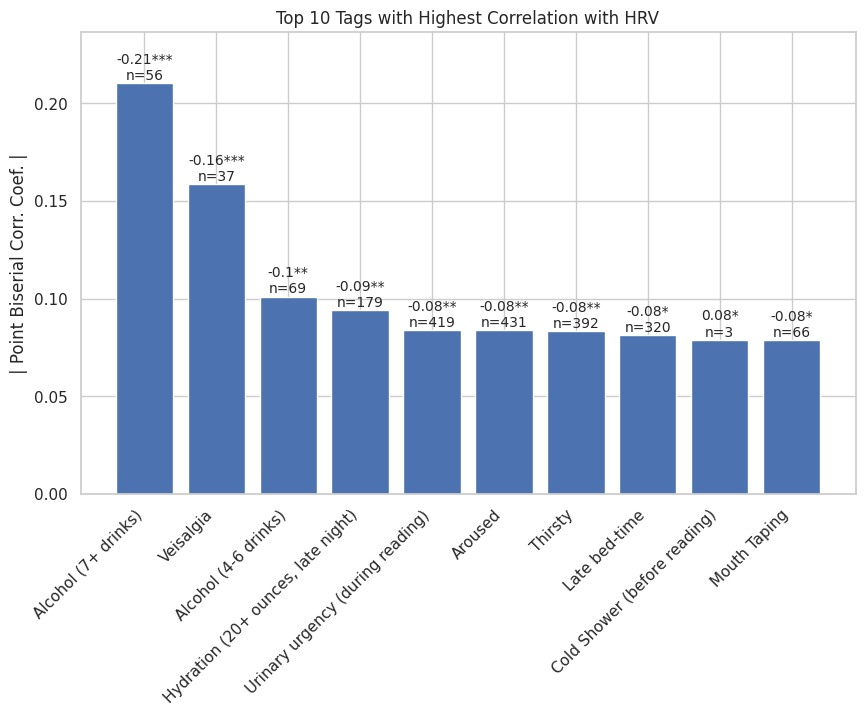

In [132]:
# Plot bar chart for HRV
plt.figure(figsize=(10, 6))
plt.bar(top_10_hrv.index, top_10_hrv.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Tags with Highest Correlation with HRV')
plt.ylabel('| Point Biserial Corr. Coef. |')

# Add correlation values and number of appearances to top of bars
for i, v in enumerate(top_10_hrv.values):
    col_name = top_10_hrv.index[i]
    corr_val = round(corr_hrv[col_name], 2)
    n = int(n_appearances[col_name])
    # Add a * above the bar if the correlation is significant
    if pval_hrv[col_name] < 0.001:
        plt.text(i, v + 0.002, f'{corr_val}***\nn={n}', ha='center', fontsize=10)
    elif pval_hrv[col_name] < 0.01:
        plt.text(i, v + 0.002, f'{corr_val}**\nn={n}', ha='center', fontsize=10)
    elif pval_hrv[col_name] < 0.05:
        plt.text(i, v + 0.002, f'{corr_val}*\nn={n}', ha='center', fontsize=10)
    else:
        plt.text(i, v + 0.002, f'{corr_val}\nn={n}', ha='center', fontsize=10)

# Set the y-axis limits with some padding
y_max = top_10_hrv.values.max() + 0.2 * top_10_hrv.values.ptp()
plt.ylim(0, y_max)
plt.savefig('images/HRVBar.png', dpi=300, bbox_inches='tight')

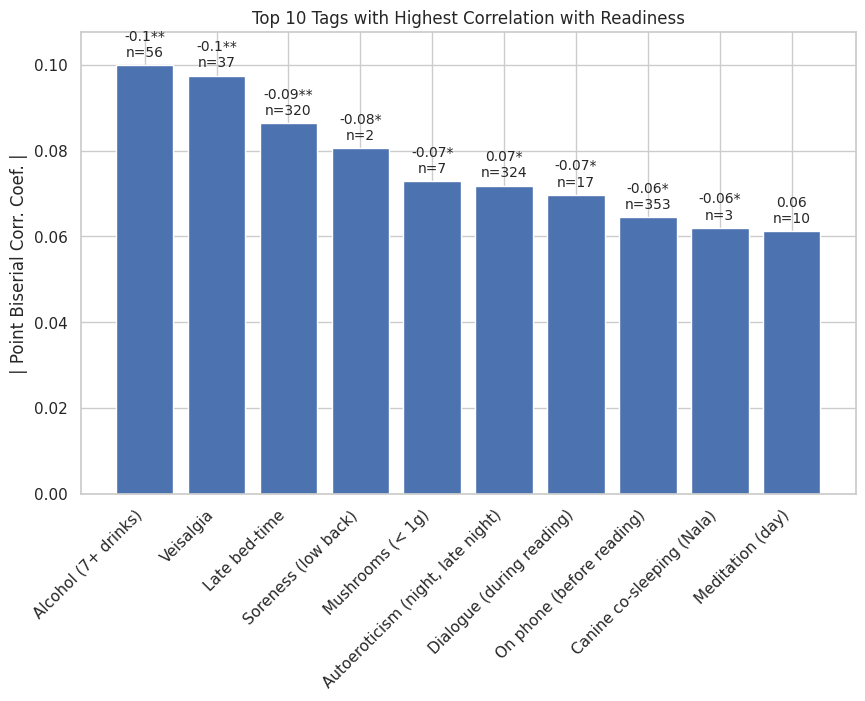

In [133]:
# Plot bar chart for Readiness
plt.figure(figsize=(10, 6))
plt.bar(top_10_readiness.index, top_10_readiness.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Tags with Highest Correlation with Readiness')
plt.ylabel('| Point Biserial Corr. Coef. |')

# Add correlation values and number of appearances to top of bars
for i, v in enumerate(top_10_readiness.values):
    col_name = top_10_readiness.index[i]
    corr_val = round(corr_readiness[col_name], 2)
    n = int(n_appearances[col_name])
    # Add a * above the bar if the correlation is significant
    if pval_readiness[col_name] < 0.001:
        plt.text(i, v + 0.002, f'{corr_val}***\nn={n}', ha='center', fontsize=10)
    elif pval_readiness[col_name] < 0.01:
        plt.text(i, v + 0.002, f'{corr_val}**\nn={n}', ha='center', fontsize=10)
    elif pval_readiness[col_name] < 0.05:
        plt.text(i, v + 0.002, f'{corr_val}*\nn={n}', ha='center', fontsize=10)
    else:
        plt.text(i, v + 0.002, f'{corr_val}\nn={n}', ha='center', fontsize=10)

# Set the y-axis limits with some padding
y_max = top_10_readiness.values.max() + 0.2 * top_10_readiness.values.ptp()
plt.ylim(0, y_max)
plt.savefig('images/ReadinessBar.png', dpi=300, bbox_inches='tight')

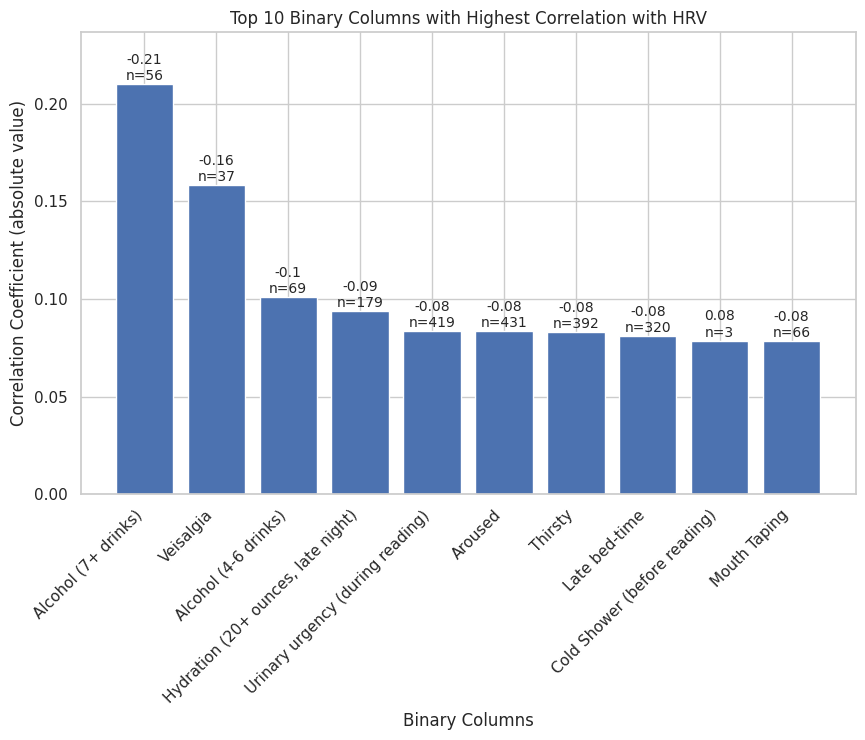

In [134]:
# Plot bar chart for HRV
plt.figure(figsize=(10, 6))
plt.bar(top_10_hrv.index, top_10_hrv.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Binary Columns with Highest Correlation with HRV')
plt.xlabel('Binary Columns')
plt.ylabel('Correlation Coefficient (absolute value)')
# Add correlation values and number of appearances to top of bars
for i, v in enumerate(top_10_hrv.values):
    col_name = top_10_hrv.index[i]
    corr_val = round(corr_hrv[col_name], 2)
    n = int(n_appearances[col_name])
    plt.text(i, v + 0.002, f'{corr_val}\nn={n}', ha='center', fontsize=10)

# Set the y-axis limits with some padding
y_max = top_10_hrv.values.max() + 0.2 * top_10_hrv.values.ptp()
plt.ylim(0, y_max)
plt.savefig('images/HRVBar.png', dpi=300, bbox_inches='tight')

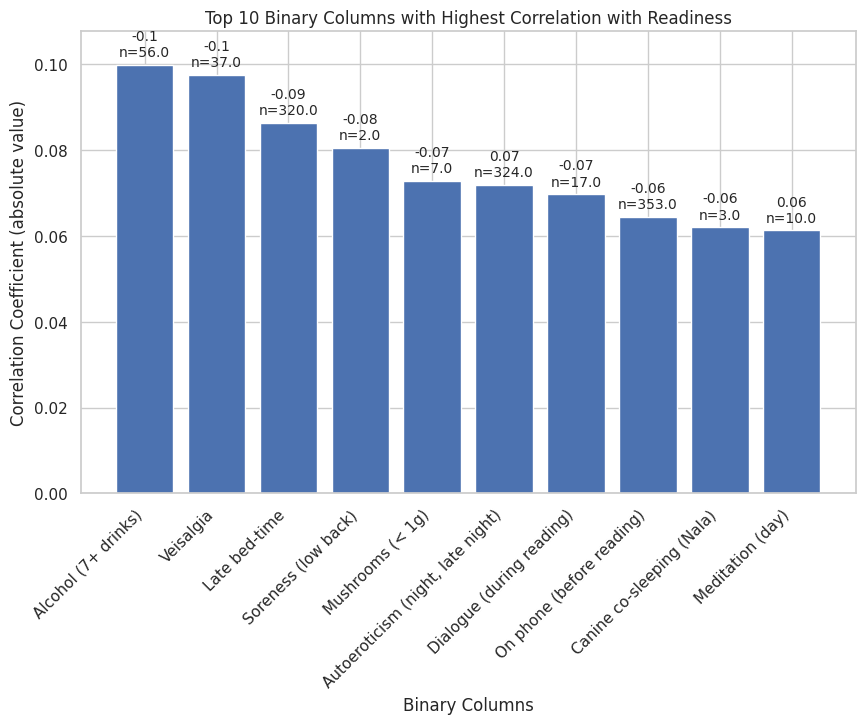

In [135]:
# Plot bar chart for readiness
plt.figure(figsize=(10, 6))
plt.bar(top_10_readiness.index, top_10_readiness.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Binary Columns with Highest Correlation with Readiness')
plt.xlabel('Binary Columns')
plt.ylabel('Correlation Coefficient (absolute value)')
# Add correlation values to top of bars
for i, v in enumerate(top_10_readiness.values):
    col_name = top_10_readiness.index[i]
    corr_val = round(corr_readiness[col_name], 2)
    n = n_appearances[col_name]
    plt.text(i, v + 0.002, f'{corr_val}\nn={n}', ha='center', fontsize=10)

# Set the y-axis limits with some padding
y_max = top_10_readiness.values.max() + 0.2 * top_10_readiness.values.ptp()
plt.ylim(0, y_max)
plt.savefig('images/ReadinessBar.png', dpi=300, bbox_inches='tight')

#### Sentiment Analysis
###### Processing
- calculating sentiment scores for all observations
- calculate average HRV for each word

In [136]:
%%time

# get overall sentiment for each note
string_df['Sentiment'] = string_df['Notes'].apply(get_sentiment_score)

# get sectional sentiment for each note
string_df[['Good', 'Bad', 'Goal']] = string_df['Notes'].apply(get_sentiment_score_by_section).apply(pd.Series)

# abreviations and non-words
junk = ['w', '4', '6', 'u2600']

# Create a list of all words in the Notes column
all_words = []
for note, hrv in zip(string_df['Notes'], string_df['HRV']):
    if isinstance(note, str):

        # Some notes consist of a book summary (from the book read during HR reading) - cut this out.
        book_emoji = '\\U0001f4d6'
        note = note.encode('unicode_escape').decode()
        note = note.split(book_emoji)[0]


        # Filter out unicode, filler words and punctuation.
        words = re.sub(r'\\u\w+', '', note.lower()) # unicode
        words = re.findall(r'\b\w+\b', words) # punctuation
        words = [re.sub(r'n(?=[A-Z])', '', word) for word in words]
        words = [word.lower() for word in words if (word.lower() not in stopwords.words() and word.lower() not in junk)]
        all_words.extend([(word, hrv) for word in words])

# Count the frequency of each word and accumulate the HRV values
word_counts = Counter()
word_hrv_sums = {}
for word, hrv in all_words:
    word = word.lower()
    word_counts[word] += 1
    if word not in word_hrv_sums:
        word_hrv_sums[word] = 0
    word_hrv_sums[word] += hrv

# Calculate the average HRV for each word
word_hrv_averages = {}
for word in word_counts:
    word_hrv_averages[word] = word_hrv_sums[word] / word_counts[word]

CPU times: user 14min 8s, sys: 1min 13s, total: 15min 22s
Wall time: 15min 33s


###### Analysis
- identify most common words
- identify words with most extreme average HRV


In [137]:
# top 10 most common words and their average HRV
top_words = word_counts.most_common(10)
print("Most common words:")
for word, count in top_words:
    avg_hrv = word_hrv_averages[word]
    print(f'{word}: {count} occurrences, average HRV: {avg_hrv:.2f}')

Most common words:
work: 666 occurrences, average HRV: 65.35
day: 503 occurrences, average HRV: 65.99
training: 404 occurrences, average HRV: 65.24
time: 398 occurrences, average HRV: 65.29
fun: 394 occurrences, average HRV: 65.57
nice: 332 occurrences, average HRV: 66.28
today: 272 occurrences, average HRV: 65.76
game: 264 occurrences, average HRV: 64.92
productive: 254 occurrences, average HRV: 66.38
yesterday: 233 occurrences, average HRV: 66.14


In [138]:
# top 10 words with highest and lowest HRV values (appearing at least 10 times)
words_10plus = [word for word in word_counts if word_counts[word] >= 10] # change this value to alter the minimum count requirement
sorted_words = sorted(words_10plus, key=lambda w: word_hrv_averages[w])

print("Words with highest HRV values:")
for word in sorted_words[-10:]: # change this value to see more/less words
    count = word_counts[word]
    avg_hrv = word_hrv_averages[word]
    print(f'{word}: {count} occurrences, average HRV: {avg_hrv:.2f}')

Words with highest HRV values:
bday: 11 occurrences, average HRV: 68.18
green: 15 occurrences, average HRV: 68.20
chocolate: 20 occurrences, average HRV: 68.35
nap: 13 occurrences, average HRV: 68.46
seidu: 12 occurrences, average HRV: 68.50
stressed: 32 occurrences, average HRV: 68.78
254: 25 occurrences, average HRV: 68.80
sac: 34 occurrences, average HRV: 68.82
gifts: 14 occurrences, average HRV: 69.36
tracking: 11 occurrences, average HRV: 69.91


In [139]:
print("Words with lowest HRV values:")
for word in sorted_words[:10]: # change this value to see more/less words
    count = word_counts[word]
    avg_hrv = word_hrv_averages[word]
    print(f'{word}: {count} occurrences, average HRV: {avg_hrv:.2f}')

Words with lowest HRV values:
yaniv: 11 occurrences, average HRV: 60.45
burlington: 10 occurrences, average HRV: 60.70
drunk: 14 occurrences, average HRV: 61.00
warm: 14 occurrences, average HRV: 61.64
ups: 16 occurrences, average HRV: 62.06
varsity: 14 occurrences, average HRV: 62.07
treadwell: 11 occurrences, average HRV: 62.09
responses: 11 occurrences, average HRV: 62.18
danny: 17 occurrences, average HRV: 62.24
ended: 23 occurrences, average HRV: 62.43


###### Visualization
- Plot ten words with highest average HRV (bar plot)
- Plot ten words with lowest average HRV (bar plot)

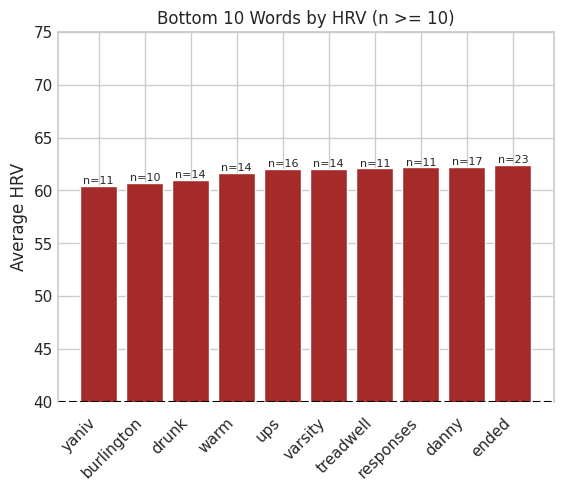

In [147]:
#### create a bar plot for each bad word
for word in sorted_words[:10]:
    count = word_counts[word]
    avg_hrv = word_hrv_averages[word]
    plt.bar(word, avg_hrv, color='brown')
    plt.text(word, avg_hrv + 0.01, str('n=' + str(count)), ha='center', va='bottom', fontsize=8)

# Set a break in the y-axis between 0 and 40
plt.gca().set_ylim([40, 75])
plt.gca().spines['bottom'].set_visible(False)  # Hide the x-axis line for the break
plt.gca().tick_params(axis='y', length=0)  # Hide the y-axis ticks for the break

# Add a line to indicate the break in the y-axis
plt.axhline(y=40, color='black', linestyle='--')

# Add axis labels and a title
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average HRV')
plt.title('Bottom 10 Words by HRV (n >= 10)')
plt.savefig('images/WorstWords.png', dpi=300, bbox_inches='tight')

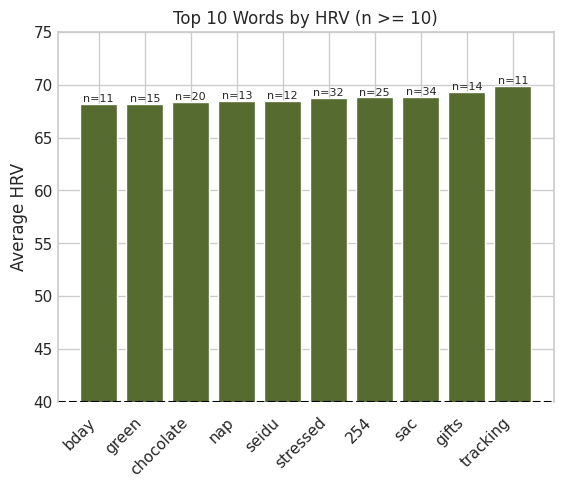

In [148]:
### create a bar plot for each good word
for word in sorted_words[-10:]:
    count = word_counts[word]
    avg_hrv = word_hrv_averages[word]
    plt.bar(word, avg_hrv, color='darkolivegreen')
    plt.text(word, avg_hrv + 0.01, str('n=' + str(count)), ha='center', va='bottom', fontsize=8)

# set a break in the y-axis between 0 and 40
plt.gca().set_ylim([40, 75])
plt.gca().spines['bottom'].set_visible(False)  # Hide the x-axis line for the break
plt.gca().tick_params(axis='y', length=0)  # Hide the y-axis ticks for the break

# add a dotted line to indicate the break in the y-axis
plt.axhline(y=40, color='black', linestyle='--')

# add axis labels and a title
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average HRV')
plt.title('Top 10 Words by HRV (n >= 10)')
plt.savefig('images/BestWords.png', dpi=300, bbox_inches='tight')

#### Supplemental
- Measure the correlation between soreness, sleep, and exercise with the standard EliteHRV biometrics.
- Look at the different exercises and the total duration of each across the 26 months.

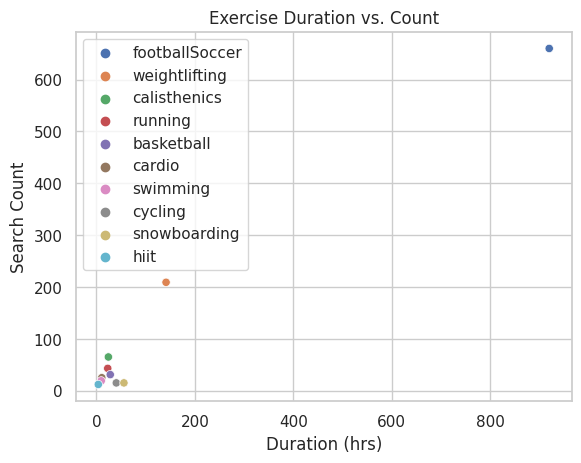

In [154]:
# Remove observations where Type = stress, weight, illness, or mood
other_df = other_df[~other_df['Type'].isin(['stress', 'weight', 'illness', 'mood'])]

try:
  other_df = other_df.drop(columns = {'Duration'}).rename(columns={'Date Time Start': 'Duration'})

  # Create Date column for the MM-DD-YY of the observation
  other_df.loc[:, 'Date'] = pd.to_datetime(other_df['Position'], format='%Y-%m-%d %H:%M:%S').dt.strftime('%m-%d-%Y')

  # Map Tags column values to Exercise or Quality column based on Type
  other_df.loc[other_df['Type'] == 'exercise', 'Exercise'] = other_df['Tags']
  other_df.loc[other_df['Type'].isin(['sleep', 'energy']), 'Quality'] = other_df['Tags']
  other_df.loc[other_df['Type'] == 'soreness', 'Intensity'] = other_df['Tags']

  # Increase dates for exercise and sleep observations by one day
  other_df.loc[other_df['Type'].isin(['exercise', 'sleep']), 'Date'] = (pd.to_datetime(other_df['Date'], format='%m-%d-%Y') + pd.DateOffset(days=1)).dt.strftime('%m-%d-%Y')

  # Drop unnecessary columns
  other_df = other_df.drop(['Tags', 'Position', 'Breathing Pattern'], axis=1)

  # Reorder columns
  other_df = other_df[['Type', 'Date', 'Exercise', 'Quality', 'Intensity', 'Duration']]

  # Use the apply() method to convert the selected columns to numeric values
  other_df['Duration'] = other_df['Duration'].apply(pd.to_numeric, errors='coerce')
  other_df['Intensity'] = other_df['Intensity'].apply(pd.to_numeric, errors='coerce')
  other_df['Quality'] = other_df['Quality'].apply(pd.to_numeric, errors='coerce')

  exercise_df = other_df[other_df['Type'] == 'exercise'].groupby('Exercise').agg({'Duration': 'sum', 'Type': 'count'})

  # Get count of each type of exercise and total duration worked out
  exercise_df.columns = ['Duration', 'Count']

  # Sort the DataFrame by Count in descending order
  exercise_df = exercise_df.sort_values(by='Count', ascending=False)

except:
  pass

# Only include the top 10 rows
top_10_df = exercise_df.head(10)

# Create a scatter plot using the filtered DataFrame
sns.scatterplot(x=top_10_df.Duration/3600, y=top_10_df.Count, hue=top_10_df.index)

# Set the title and axis labels
plt.title('Exercise Duration vs. Count')
plt.xlabel('Duration (hrs)')
plt.ylabel('Search Count')

# Only include the top 10 values in the legend
handles, labels = plt.gca().get_legend_handles_labels()
top_10_handles = handles[:10]
top_10_labels = labels[:10]
plt.legend(top_10_handles, top_10_labels)

# Show the plot
plt.savefig('exercise-summary.png', dpi=300, bbox_inches='tight')